In [ ]:
import math
import numpy as np 
import numpy.linalg as la
import matplotlib.pyplot as plt

# Optimizers



# Single-step time integration function ---------------------------
def forward_euler(xn, vn, fn, m, dt):
	return (xn + dt*vn, vn + dt*fn(xn)/m[:, None])

def symplectic_euler(xn, vn, fn, m, dt):
	vn1 = vn + dt*fn(xn)/m
	return (xn + dt*vn1, vn1)

def backward_euler(xn, vn, fn, m, dt):
	pass
	

# Position-dependent force functions ------------------------------
def f_gravity(center, mass, G):
	def force(xn):
		disp = center - xn                       # shape (N,D)
		r = la.norm(disp, axis=1)                # (N,1)
		r3 = np.power(r, 3) + 1e-8               # (N,1)
		return disp * (G * mass / r3)[:, None]   # convert r3 to (1, N)
	 
	return force

def f_center(center, k):
	def force(xn):
		return k*(center - xn)/la.norm(center - xn)
	return force

	


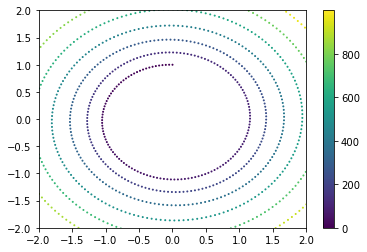

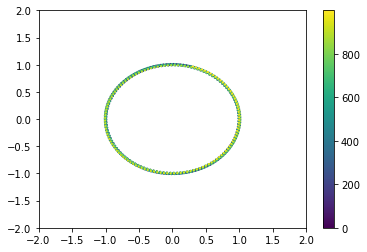

In [42]:
for step_method in [forward_euler, symplectic_euler]:

	# Initial conditions --------------------------------
	points = np.array([
		[0, 1]
	])

	velocities = np.array([
		[-1, 0],
	])

	masses = np.array(
		[1]
	)


	# Parameters -----------------------------------------
	steps 			= 1000
	dt 				= 0.05
	point_history 	= np.zeros((steps, points.shape[0], points.shape[1]))
	force_func 		= f_center(np.array([0,0]), 1)


	# Simulation loop ------------------------------------
	point_history[0] = points
	for step_idx in range(1, steps):
		points, velocities = step_method(points, velocities, force_func, masses, dt)
		point_history[step_idx] = points


	# Plot points over time ------------------------------
	plt.scatter(point_history[:,0,0], point_history[:,0,1], c=range(steps), cmap='viridis', s=1)
	plt.xlim(-2, 2)
	plt.ylim(-2, 2)
	plt.colorbar()
	plt.show()


